# Notebook 14 - Post-V3 End-to-End Bottleneck Reassessment

Diagnóstico pós-promoção do `CitationDetector V3`. Não há novas regras: a pipeline é exclusivamente `CitationDetector V3 -> CitationParser V1 -> CitationResolver V1`. Gold é usado somente para matching e avaliação.

In [1]:
from __future__ import annotations
from collections import Counter
from pathlib import Path
import hashlib, time
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from bracis_jusbrasil.cases import build_case_index
from bracis_jusbrasil.citations import CitationCandidate, CitationDetector, CitationParser, CitationResolver
from bracis_jusbrasil.database import connect_database

ROOT=Path.cwd(); DATASET=next(p for p in (ROOT/'material_desafio_jusbrasil_bracis',ROOT.parent/'material_desafio_jusbrasil_bracis') if p.is_dir())
DB_PATH=DATASET/'desafio1_bracis.db'; GOLD_PATH=DATASET/'goldenset.xlsx'; TEXT_DIR=DATASET/'txt'
EXPECTED_HASH='d759681be82ee00f383b49a5c76c42dd475564e042272e00730252468dcb6e71'
assert hashlib.sha256(DB_PATH.read_bytes()).hexdigest()==EXPECTED_HASH
texts={p.stem:p.read_text(encoding='utf-8') for p in sorted(TEXT_DIR.glob('*.txt'))}
gold=pd.read_excel(GOLD_PATH,sheet_name='goldenset',engine='openpyxl').reset_index(names='gold_idx'); gold['nivel']='N'+gold.nivel.astype(str).str.removeprefix('N')
assert len(texts)==26 and len(gold)==225 and gold.classificacao.value_counts().to_dict()=={'real':96,'inventada':64,'incompleta':65}
with connect_database(DB_PATH,read_only=True) as c: assert c.execute('PRAGMA integrity_check').fetchone()[0]=='ok'
print('dataset: 26 documentos, 225 citações; real/inventada/incompleta=96/64/65; integrity_check=ok')

dataset: 26 documentos, 225 citações; real/inventada/incompleta=96/64/65; integrity_check=ok


In [2]:
def iou(a,b,c,d): return max(0,min(b,d)-max(a,c))/(max(b,d)-min(a,c)) if max(b,d)>min(a,c) else 0.0
def family_for(text,typ):
    import re
    if typ=='lei': return 'lei_dispositivo_com_diploma' if re.search(r'\bart(?:igo)?[.]?\s*\d+',text,re.I) and re.search(r'\b(?:Lei|Constituiç|C[oó]digo|CLT|CPC|CPP|CC|CDC|CPM)',text,re.I) else 'lei_dispositivo_sem_diploma' if re.search(r'\bart(?:igo)?[.]?\s*\d+',text,re.I) else 'lei_referencia_geral'
    if re.search(r'\bS[ÚU]MULA(?:\s+VINCULANTE)?\s*(?:N[ºO.]?\s*)?\d+',text,re.I): return 'sumula_numerada'
    if re.search(r'\b\d{3,7}\s*-\s*\d{2}\s*[.]\s*\d{4}\s*[.]\s*\d\s*[.]\s*\d{2}\s*[.]\s*\d{4}\b',text): return 'processo_cnj'
    if re.search(r'\b(?:AREsp|REsp|AgInt|AgRg|EDcl|HC|Rcl|ADI|ADPF|RE|AI|MS|RR|AIRR|AP|RO|Agravo|Recurso Especial|Recurso Extraordinário|Habeas Corpus|Reclamação)\b',text,re.I) and re.search(r'\d',text): return 'processo_ou_recurso_numerado'
    if re.search(r'\b(?:STF|STJ|TSE|TST|STM)\b',text,re.I) and re.search(r'\b(?:19|20)\d{2}\b',text): return 'jurisprudencia_tribunal_contextual'
    return 'jurisprudencia_referencia_geral'
FIELDS={'processo_ou_recurso_numerado':('numero_normalizado','classe_raw','uf'),'processo_cnj':('numero_normalizado',),'sumula_numerada':('sumula_numero','tribunal'),'lei_dispositivo_com_diploma':('artigo','diploma_normalizado','law_number'),'lei_dispositivo_sem_diploma':('artigo',),'lei_referencia_geral':('diploma_normalizado',),'jurisprudencia_tribunal_contextual':('tribunal','relator_raw','ano'),'jurisprudencia_referencia_geral':()}
def val(p,f): return p.tribunal if f=='tribunal' else p.data.get(f)
def identity_available(p): return any(val(p,f) is not None for f in FIELDS[p.family])
def identity_equal(a,b): return identity_available(b) and a.family==b.family and all(val(a,f)==val(b,f) for f in FIELDS[b.family])
def value_visible(oracle_parsed,text):
    import re
    digits=re.sub(r'\D','',text)
    for field in FIELDS[oracle_parsed.family]:
        expected=val(oracle_parsed,field)
        if not expected: continue
        if field in {'numero_normalizado','sumula_numero','law_number','artigo'} and str(expected) not in digits: return False
        if field=='tribunal' and not re.search(r'\b(?:STF|STJ|TSE|TST|STM|Supremo Tribunal Federal|Superior Tribunal de Justiça|Tribunal Superior Eleitoral|Tribunal Superior do Trabalho|Superior Tribunal Militar)\b',text,re.I): return False
        if field=='classe_raw' and not re.search(re.escape(str(expected)),text,re.I): return False
        if field=='uf' and not re.search(r'(?<![A-Z])'+re.escape(str(expected))+r'(?![A-Z])',text): return False
        if field in {'diploma_normalizado','relator_raw','ano'} and str(expected).upper() not in text.upper(): return False
    return True
def match(pred):
    pairs=[]
    for doc,gs in gold.groupby('documento_id'):
        ps=pred[pred.documento_id.eq(doc)]
        for g in gs.itertuples():
            for p in ps.itertuples():
                x=iou(g.inicio,g.fim,p.start,p.end)
                if x>=.5: pairs.append((x,g.gold_idx,p.pred_idx,g.inicio==p.start and g.fim==p.end))
    usedg,usedp=set(),set(); out=[]
    for x,g,p,e in sorted(pairs,key=lambda z:(-z[0],z[1],z[2])):
        if g not in usedg and p not in usedp: out.append((g,p,x,e)); usedg.add(g); usedp.add(p)
    return pd.DataFrame(out,columns=['gold_idx','pred_idx','iou','exact'])
def run():
    rows=[]; started=time.perf_counter(); parser=CitationParser()
    with connect_database(DB_PATH,read_only=True) as c:
        resolver=CitationResolver(case_index=build_case_index(c),connection=c)
        for doc,text in texts.items():
            for candidate in CitationDetector().detect(text):
                parsed=parser.parse(candidate); result=resolver.resolve(parsed)
                rows.append({'documento_id':doc,'start':candidate.start,'end':candidate.end,'text':candidate.text,'rule':candidate.rule,'candidate_family':candidate.family,'parsed':parsed,'result':result})
    return pd.DataFrame(rows).reset_index(names='pred_idx'),time.perf_counter()-started
predictions,elapsed=run(); matches=match(predictions)
assert (len(predictions),len(matches),len(predictions)-len(matches),len(gold)-len(matches),int(matches.exact.sum()))==(206,119,87,106,61)
print(f'V3: predictions={len(predictions)}, TP={len(matches)}, FP={len(predictions)-len(matches)}, FN={len(gold)-len(matches)}, exact={int(matches.exact.sum())}, tempo={elapsed:.3f}s')
_V2_UF_TAIL=__import__('re').compile(r'(?:/\s*|\(\s*)(?:AC|AL|AP|AM|BA|CE|DF|ES|GO|MA|MT|MS|MG|PA|PB|PR|PE|PI|RJ|RN|RS|RO|RR|SC|SP|SE|TO)(?:[ \t\u00a0]*\))?$')
def historical_v2(text):
    out=[]
    for c in CitationDetector().detect(text):
        tail=_V2_UF_TAIL.search(c.text) if c.rule=='processo_ou_recurso' else None
        if tail: out.append(CitationCandidate(c.start,c.start+tail.start(),text[c.start:c.start+tail.start()],c.rule,c.family))
        else: out.append(c)
    return tuple(out)
v2_predictions=pd.DataFrame([{'documento_id':d,'start':c.start,'end':c.end,'text':c.text,'rule':c.rule,'candidate_family':c.family,'candidate':c} for d,t in texts.items() for c in historical_v2(t)]).reset_index(names='pred_idx'); v2_matches=match(v2_predictions); assert (len(v2_predictions),len(v2_matches),int(v2_matches.exact.sum()))==(206,117,25)

V3: predictions=206, TP=119, FP=87, FN=106, exact=61, tempo=1.297s


In [3]:
parser=CitationParser(); oracle={g.gold_idx:parser.parse(CitationCandidate(0,len(texts[g.documento_id][g.inicio:g.fim]),texts[g.documento_id][g.inicio:g.fim],'oracle',family_for(texts[g.documento_id][g.inicio:g.fim],g.tipo))) for g in gold.itertuples()}
with connect_database(DB_PATH,read_only=True) as c: resolver=CitationResolver(case_index=build_case_index(c),connection=c); oracle_results={i:resolver.resolve(p) for i,p in oracle.items()}
assert sum(oracle[i].family=='processo_cnj' and bool(oracle[i].data.get('numero_normalizado')) for i in oracle)==25
assert sum(oracle[i].family=='processo_ou_recurso_numerado' and bool(oracle[i].data.get('numero_normalizado')) for i in oracle)==73
assert sum(oracle[i].family=='processo_ou_recurso_numerado' and bool(oracle[i].data.get('uf')) for i in oracle)==66
assert sum(oracle[i].family=='sumula_numerada' and bool(oracle[i].data.get('sumula_numero')) for i in oracle)==10
bygold={x.gold_idx:x for x in matches.itertuples()}; bypred=predictions.set_index('pred_idx')
rows=[]
for g in gold.itertuples():
    op,orr=oracle[g.gold_idx],oracle_results[g.gold_idx]; m=bygold.get(g.gold_idx)
    if m is None:
        overlap=any(iou(g.inicio,g.fim,p.start,p.end)>0 for p in predictions[predictions.documento_id.eq(g.documento_id)].itertuples()); rows.append({'gold_idx':g.gold_idx,'documento_id':g.documento_id,'nivel':g.nivel,'classificacao':g.classificacao,'tipo':g.tipo,'family':op.family,'matched':False,'identity':False,'identity_available':identity_available(op),'parser_gap':False,'correct':False,'first_blocker':'detector_boundary_failure' if overlap else 'detector_miss','parsed':None,'result':None,'oracle_result':orr}); continue
    p=bypred.loc[m.pred_idx]; ident=identity_equal(p.parsed,op); correct=g.classificacao=='real' and p.result.status=='resolved' and p.result.id_canonico==g.id_canonico
    blocker='resolved_correct' if correct else 'resolved_wrong' if p.result.status=='resolved' else 'detector_family_mismatch' if p.parsed.family!=op.family else 'resolver_'+p.result.status if ident else 'parser_gap' if value_visible(op,p.text) else 'detector_boundary_failure'
    rows.append({'gold_idx':g.gold_idx,'documento_id':g.documento_id,'nivel':g.nivel,'classificacao':g.classificacao,'tipo':g.tipo,'family':op.family,'matched':True,'identity':ident,'identity_available':identity_available(op),'parser_gap':not ident,'correct':correct,'first_blocker':blocker,'parsed':p.parsed,'result':p.result,'oracle_result':orr,'candidate_text':p.text,'iou':m.iou,'exact':m.exact})
tracking=pd.DataFrame(rows); real=tracking[tracking.classificacao.eq('real')]; unresolved=real[~real.correct]
assert len(real)==96 and len(unresolved)==67 and real.first_blocker.value_counts().sum()==96
assert int(real.correct.sum())==29 and int(((real.result.map(lambda x:x is not None and x.status=='resolved')) & ~real.correct).sum())==0
first_order=['detector_miss','detector_boundary_failure','detector_family_mismatch','parser_gap','resolver_insufficient','resolver_ambiguous','resolver_no_match','resolved_wrong','resolved_correct']
v3_blockers=real.first_blocker.value_counts().reindex(first_order,fill_value=0).rename('V3'); v2=pd.Series({'detector_miss':19,'detector_boundary_failure':21,'detector_family_mismatch':5,'parser_gap':0,'resolver_insufficient':22,'resolver_ambiguous':1,'resolver_no_match':1,'resolved_wrong':0,'resolved_correct':27},name='V2'); comparison=pd.concat([v2,v3_blockers],axis=1).fillna(0).astype(int); comparison['delta']=comparison.V3-comparison.V2; display(comparison)
v2_records=[]
for r in v2_predictions.itertuples():
    parsed=parser.parse(r.candidate); v2_records.append({'pred_idx':r.pred_idx,'documento_id':r.documento_id,'start':r.start,'end':r.end,'text':r.text,'parsed':parsed,'result':resolver.resolve(parsed)})
v2_records=pd.DataFrame(v2_records); v2_by_gold={x.gold_idx:x.pred_idx for x in v2_matches.itertuples()}; v2_correct={g for g,pidx in v2_by_gold.items() if g in set(gold[gold.classificacao.eq('real')].gold_idx) and v2_records.loc[v2_records.pred_idx.eq(pidx),'result'].iloc[0].status=='resolved' and v2_records.loc[v2_records.pred_idx.eq(pidx),'result'].iloc[0].id_canonico==int(gold.loc[gold.gold_idx.eq(g),'id_canonico'].iloc[0])}; v3_correct=set(real[real.correct].gold_idx); new_ids=sorted(v3_correct-v2_correct)
def nearest_v2(gid):
    g=gold.loc[gold.gold_idx.eq(gid)].iloc[0]; candidates=v2_records[v2_records.documento_id.eq(g.documento_id)].copy(); candidates['iou']=candidates.apply(lambda r:iou(g.inicio,g.fim,r.start,r.end),axis=1); return candidates.sort_values(['iou','pred_idx'],ascending=[False,True]).iloc[0] if len(candidates) else None
new_id_rows=[]
for gid in new_ids:
    g=gold.loc[gold.gold_idx.eq(gid)].iloc[0]; v3row=bypred.loc[bygold[gid].pred_idx]; v2row=nearest_v2(gid); v2_blocker='detector_boundary_failure' if v2row is not None and v2row.iou>0 else 'detector_miss'; new_id_rows.append({'gold_idx':gid,'documento_id':g.documento_id,'gold_family':real.loc[real.gold_idx.eq(gid),'family'].iloc[0],'gold':texts[g.documento_id][g.inicio:g.fim],'candidate V2':v2row.text if v2row is not None else None,'ParsedCitation V2':v2row.parsed if v2row is not None else None,'ResolutionResult V2':v2row.result if v2row is not None else None,'candidate V3':v3row.text,'ParsedCitation V3':v3row.parsed,'ResolutionResult V3':v3row.result,'V2 blocker':v2_blocker})
print('V3 correct IDs=29/96; unresolved real=67; first blockers somam 96; novos IDs:',new_ids); display(pd.DataFrame(new_id_rows))

,V2,V3,delta
detector_miss,19,19,0
detector_boundary_failure,21,19,-2
detector_family_mismatch,5,5,0
parser_gap,0,0,0
resolver_insufficient,22,22,0
resolver_ambiguous,1,1,0
resolver_no_match,1,1,0
resolved_wrong,0,0,0
resolved_correct,27,29,2


V3 correct IDs=29/96; unresolved real=67; first blockers somam 96; novos IDs: [53, 89]


,gold_idx,documento_id,gold_family,gold,candidate V2,ParsedCitation V2,ResolutionResult V2,candidate V3,ParsedCitation V3,ResolutionResult V3,V2 blocker
0,53,gen_n1_007,processo_ou_recurso_numerado,AgInt na Rcl 36.670/SP,Rcl 36.670,ParsedCitation(family='processo_ou_recurso_num...,"ResolutionResult(status='resolved', id_canonic...",Rcl 36.670/SP,ParsedCitation(family='processo_ou_recurso_num...,"ResolutionResult(status='resolved', id_canonic...",detector_boundary_failure
1,89,gen_n1_010,processo_ou_recurso_numerado,Agravo Interno no Agravo em Recurso Especial n...,Recurso Especial nº 1807643,ParsedCitation(family='processo_ou_recurso_num...,"ResolutionResult(status='resolved', id_canonic...",Recurso Especial nº 1807643/RS,ParsedCitation(family='processo_ou_recurso_num...,"ResolutionResult(status='resolved', id_canonic...",detector_boundary_failure


In [4]:
detector_remaining=unresolved[unresolved.first_blocker.str.startswith('detector')]; display(detector_remaining.groupby(['first_blocker','family']).size().rename('count').reset_index())
detector_misses=unresolved[unresolved.first_blocker.eq('detector_miss')].copy(); detector_misses['oracle-resolvable']=detector_misses.oracle_result.map(lambda x:x.status=='resolved'); print('High-value detector misses:',int(detector_misses['oracle-resolvable'].sum()),'deferred:',int((~detector_misses['oracle-resolvable']).sum())); display(detector_misses.groupby(['family','nivel','oracle-resolvable']).size().rename('count').reset_index())
boundary=unresolved[unresolved.first_blocker.eq('detector_boundary_failure')].copy(); boundary['lost_field']=boundary.apply(lambda r:'numero' if r.oracle_result.status=='resolved' and not r.identity else 'classe/UF/estrutura',axis=1); boundary['immediate-ID-potential']=boundary.oracle_result.map(lambda x:x.status=='resolved'); display(boundary.groupby(['lost_field','immediate-ID-potential']).size().rename('count').reset_index())
family_mismatch=unresolved[unresolved.first_blocker.eq('detector_family_mismatch')].copy(); family_mismatch['immediate-ID-potential']=family_mismatch.oracle_result.map(lambda x:x.status=='resolved'); display(family_mismatch[['documento_id','family','candidate_text','immediate-ID-potential']])
parser_blockers=unresolved[unresolved.first_blocker.eq('parser_gap')]; print('Parser first blockers:',len(parser_blockers)); display(parser_blockers[['documento_id','family','candidate_text']])
resolver_blockers=unresolved[unresolved.first_blocker.str.startswith('resolver_')]; display(resolver_blockers.groupby(['first_blocker','family']).size().rename('count').reset_index())
insufficient=resolver_blockers[resolver_blockers.first_blocker.eq('resolver_insufficient')].copy(); insufficient['identity_pool']=insufficient.identity_available & insufficient.identity; display(insufficient.groupby(['family','identity_pool']).size().rename('count').reset_index())
cnj=real[real.family.eq('processo_cnj')]; legal=real[real.family.str.startswith('lei_')]; sumulas=real[real.family.eq('sumula_numerada')]; general=real[real.family.isin(['jurisprudencia_referencia_geral','jurisprudencia_tribunal_contextual'])]
def family_summary(frame): return {'real':len(frame),'detector blocker':int(frame.first_blocker.str.startswith('detector').sum()),'parser blocker':int(frame.first_blocker.eq('parser_gap').sum()),'resolver blocker':int(frame.first_blocker.str.startswith('resolver_').sum()),'semantic/contextual':int(((frame.first_blocker.eq('resolver_insufficient'))&~frame.identity_available).sum()),'success':int(frame.correct.sum())}
family_table=pd.DataFrame({f:family_summary(tracking[(tracking.classificacao=='real')&(tracking.family==f)]) for f in sorted(tracking[tracking.classificacao=='real'].family.unique())}).T; display(family_table)
display(pd.DataFrame([{'pool':'CNJ','real':len(cnj),'detector OK':int(cnj.matched.sum()),'parser OK':int(cnj.identity.sum()),'resolver insufficient':int((cnj.result.map(lambda x:x is not None and x.reason=='cnj_resolution_disabled')).sum()),'detector blockers':int(cnj.first_blocker.str.startswith('detector').sum())},{'pool':'legal','real':len(legal),'detector OK':int(legal.matched.sum()),'parser OK':int(legal.identity.sum()),'resolver insufficient':int((legal.first_blocker=='resolver_insufficient').sum()),'detector blockers':int(legal.first_blocker.str.startswith('detector').sum())},{'pool':'súmulas','real':len(sumulas),'detector OK':int(sumulas.matched.sum()),'parser OK':int(sumulas.identity.sum()),'resolver insufficient':int((sumulas.first_blocker=='resolver_insufficient').sum()),'detector blockers':int(sumulas.first_blocker.str.startswith('detector').sum())},{'pool':'jurisprudência geral/contextual','real':len(general),'detector OK':int(general.matched.sum()),'parser OK':int(general.identity.sum()),'resolver insufficient':int((general.first_blocker=='resolver_insufficient').sum()),'detector blockers':int(general.first_blocker.str.startswith('detector').sum())}]))

,first_blocker,family,count
0,detector_boundary_failure,lei_dispositivo_com_diploma,9
1,detector_boundary_failure,processo_cnj,2
2,detector_boundary_failure,processo_ou_recurso_numerado,5
3,detector_boundary_failure,sumula_numerada,3
4,detector_family_mismatch,lei_dispositivo_com_diploma,1
5,detector_family_mismatch,processo_cnj,4
6,detector_miss,jurisprudencia_referencia_geral,13
7,detector_miss,processo_ou_recurso_numerado,6


High-value detector misses: 5 deferred: 14


,family,nivel,oracle-resolvable,count
0,jurisprudencia_referencia_geral,N1,False,2
1,jurisprudencia_referencia_geral,N2,False,11
2,processo_ou_recurso_numerado,N1,False,1
3,processo_ou_recurso_numerado,N1,True,1
4,processo_ou_recurso_numerado,N2,True,4


,lost_field,immediate-ID-potential,count
0,classe/UF/estrutura,False,12
1,numero,True,7


,documento_id,family,candidate_text,immediate-ID-potential
64,gen_n1_008,processo_cnj,TST-ED-E-ED-RR-3400-05.2011,False
66,gen_n1_008,lei_dispositivo_com_diploma,art. 818,False
132,gen_n2_003,processo_cnj,TST- ED - E-ED-RR-41200-79.2011,False
138,gen_n2_003,processo_cnj,TST-ED-E-ED-ARR-1099-66.2011,False
154,gen_n2_005,processo_cnj,TST- ED-E-ED-RR-160000-97.2010,False


...

,documento_id,family,candidate_text


,first_blocker,family,count
0,resolver_ambiguous,processo_ou_recurso_numerado,1
1,resolver_insufficient,lei_dispositivo_com_diploma,4
2,resolver_insufficient,processo_cnj,17
3,resolver_insufficient,sumula_numerada,1
4,resolver_no_match,processo_ou_recurso_numerado,1


,family,identity_pool,count
0,lei_dispositivo_com_diploma,True,4
1,processo_cnj,True,17
2,sumula_numerada,True,1


,real,detector blocker,parser blocker,resolver blocker,semantic/contextual,success
jurisprudencia_referencia_geral,13,13,0,0,0,0
lei_dispositivo_com_diploma,14,10,0,4,0,0
processo_cnj,23,6,0,17,0,0
processo_ou_recurso_numerado,42,11,0,2,0,29
sumula_numerada,4,3,0,1,0,0


,pool,real,detector OK,parser OK,resolver insufficient,detector blockers
0,CNJ,23,21,17,17,6
1,legal,14,5,4,4,10
2,súmulas,4,4,1,1,3
3,jurisprudência geral/contextual,13,0,0,0,13


,component,max immediate correct-ID gain
0,Detector V4,12
1,Parser V2,0
2,Resolver V2 structural,22
3,semantic/contextual,N/A


,cases,% of 67
investment,,
Semantic/contextual,31,46.268657
Resolver structural,22,32.835821
Detector,12,17.910448
Ambiguous/no-match irreducible,2,2.985075


Detector-only immediate upper bound: 12 ; Parser-only: 0 ; Resolver structural research pool: 22 ; semantic/contextual pool: 31


result,resolved,no_match,ambiguous,insufficient,missing
classificacao,,,,,
real,29,3,1,30,33
inventada,0,25,0,19,20
incompleta,0,0,0,12,53


,gold_real,detected,correct_ID,first detector blocker,resolver blocker
nivel,,,,,
N1,52,38,20,18,14
N2,44,25,9,25,10


result
resolved         3
no_match         0
ambiguous        0
insufficient    84
Name: V3 formal FPs, dtype: int64

Determinismo V3: 3/3 execuções idênticas


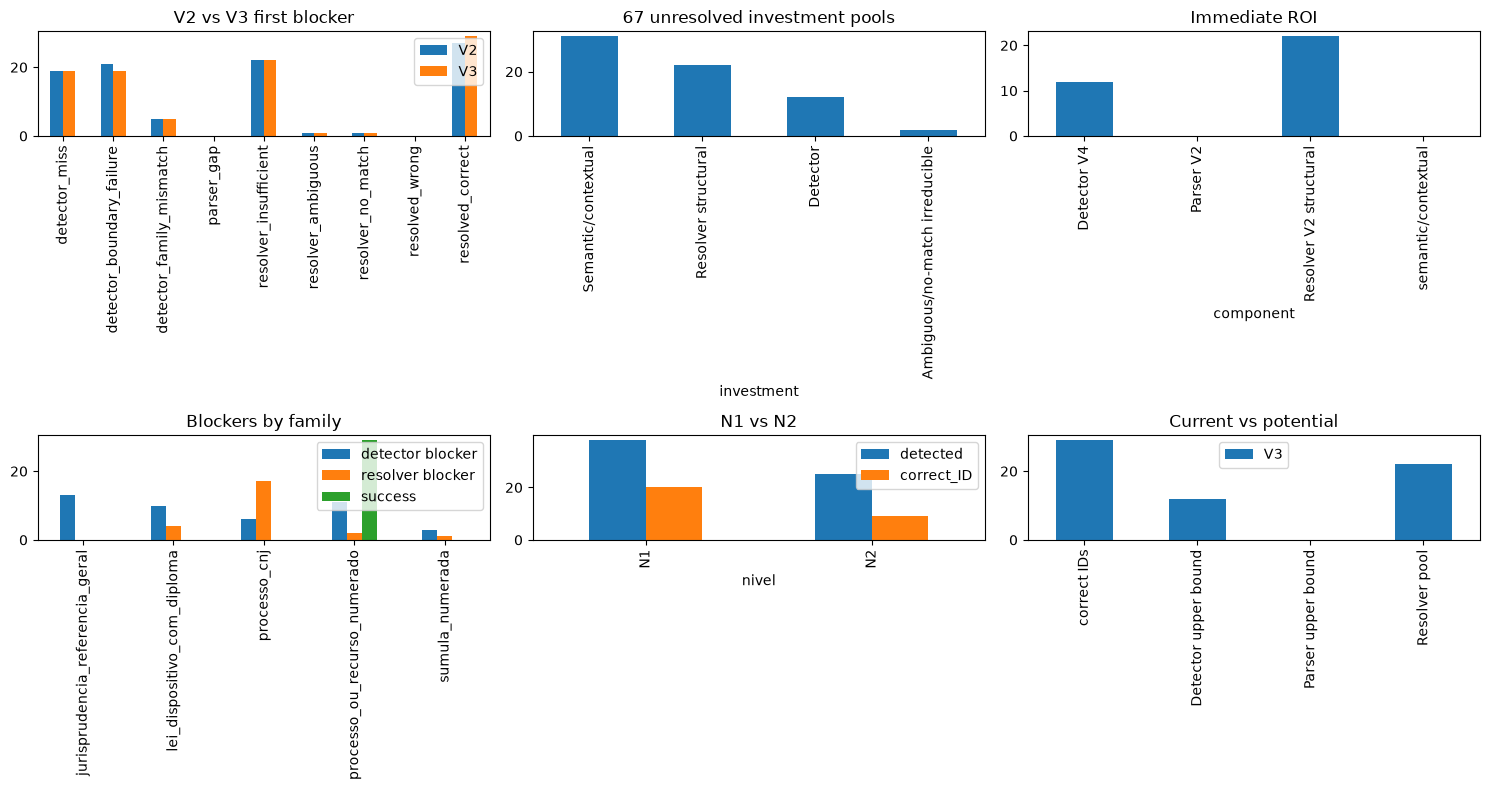

In [5]:
# Immediate ROI: oracle spans são contrafactuais diagnósticos, não regras nem promessa de implementação.
detector_roi=int(((unresolved.first_blocker.str.startswith('detector')) & unresolved.oracle_result.map(lambda x:x.status=='resolved')).sum())
parser_roi=int(((unresolved.first_blocker=='parser_gap') & unresolved.oracle_result.map(lambda x:x.status=='resolved')).sum())
resolver_pool=insufficient[insufficient.identity_pool]; semantic_pool=unresolved[(unresolved.first_blocker=='resolver_insufficient') & ~unresolved.identity_available]
roi=pd.DataFrame({'component':['Detector V4','Parser V2','Resolver V2 structural','semantic/contextual'],'max immediate correct-ID gain':[detector_roi,parser_roi,len(resolver_pool),'N/A']}); display(roi)
def pool(row):
    if row.first_blocker=='parser_gap': return 'Parser'
    if row.first_blocker.startswith('resolver_') and row.first_blocker not in {'resolver_ambiguous','resolver_no_match'} and row.identity_available: return 'Resolver structural'
    if row.first_blocker.startswith('resolver_') and row.first_blocker not in {'resolver_ambiguous','resolver_no_match'}: return 'Semantic/contextual'
    if row.first_blocker in {'resolver_ambiguous','resolver_no_match'}: return 'Ambiguous/no-match irreducible'
    if row.first_blocker.startswith('detector') and row.oracle_result.status=='resolved': return 'Detector'
    return 'Semantic/contextual'
unresolved=unresolved.copy(); unresolved['investment']=unresolved.apply(pool,axis=1); pools=unresolved.investment.value_counts().rename_axis('investment').rename('cases').to_frame(); pools['% of 67']=pools.cases/67*100; display(pools); print('Detector-only immediate upper bound:',detector_roi,'; Parser-only:',parser_roi,'; Resolver structural research pool:',len(resolver_pool),'; semantic/contextual pool:',int((unresolved.investment=='Semantic/contextual').sum()))
invented=tracking[tracking.classificacao.eq('inventada')]; incomplete=tracking[tracking.classificacao.eq('incompleta')]; matrix=pd.crosstab(tracking.classificacao,tracking.result.map(lambda x:x.status if x is not None else 'missing')).reindex(index=['real','inventada','incompleta'],columns=['resolved','no_match','ambiguous','insufficient','missing'],fill_value=0); display(matrix)
n1n2=real.groupby('nivel').agg(gold_real=('gold_idx','size'),detected=('matched','sum'),correct_ID=('correct','sum')); n1n2['first detector blocker']=real.assign(d=real.first_blocker.str.startswith('detector')).groupby('nivel').d.sum(); n1n2['resolver blocker']=real.assign(d=real.first_blocker.str.startswith('resolver_')).groupby('nivel').d.sum(); display(n1n2)
fps=predictions[~predictions.pred_idx.isin(matches.pred_idx)]; fp_states=fps.result.map(lambda x:x.status).value_counts().reindex(['resolved','no_match','ambiguous','insufficient'],fill_value=0); display(fp_states.rename('V3 formal FPs'))
assert int(matrix.loc['real'].sum())==96 and int(matrix.loc['inventada'].sum())==64 and int(matrix.loc['incompleta'].sum())==65
def run_signature(frame): return tuple((r.documento_id,r.start,r.end,r.text,r.rule,r.candidate_family,repr(r.parsed),repr(r.result)) for r in frame.itertuples())
determinism_runs=[run()[0] for _ in range(3)]; assert run_signature(determinism_runs[0])==run_signature(determinism_runs[1])==run_signature(determinism_runs[2]); print('Determinismo V3: 3/3 execuções idênticas')
fig,ax=plt.subplots(2,3,figsize=(15,8)); comparison[['V2','V3']].plot.bar(ax=ax[0,0],title='V2 vs V3 first blocker'); pools.cases.plot.bar(ax=ax[0,1],title='67 unresolved investment pools'); roi.set_index('component')['max immediate correct-ID gain'].replace('N/A',0).plot.bar(ax=ax[0,2],title='Immediate ROI'); family_table[['detector blocker','resolver blocker','success']].plot.bar(ax=ax[1,0],title='Blockers by family'); n1n2[['detected','correct_ID']].plot.bar(ax=ax[1,1],title='N1 vs N2'); pd.DataFrame({'V3': [29,detector_roi,parser_roi,len(resolver_pool)]},index=['correct IDs','Detector upper bound','Parser upper bound','Resolver pool']).plot.bar(ax=ax[1,2],title='Current vs potential'); plt.tight_layout(); plt.show()

## Conclusão

A matriz `comparison` é a atribuição central. `first blocker` descreve onde a execução atual parou; os pools e `roi` usam contrafactuais oracle somente para estimar retorno marginal. `Resolver structural` é potencial de investigação, não IDs garantidos.

Candidate filtering: **AINDA NÃO É POSSÍVEL CONCLUIR**.

A decisão A-E deve ser lida assim: se o Detector-only immediate upper bound for pequeno ou heterogêneo, não há justificativa para V4; se o pool estrutural do Resolver for maior, o próximo experimento é Resolver V2. Famílias gerais/contextuais sem identidade ficam separadas para investigação semântica. Nenhuma regra nova é implementada neste notebook.